# Introduction à l'Intelligence Artificielle

Bienvenue dans ce cours d'introduction à l'IA ! Ce notebook est conçu pour les débutants et couvre tout ce qu'il faut savoir pour démarrer, avec des explications claires, des illustrations et du code pratique.

## Table des matières
1. [Introduction à l'IA](#1.-Introduction-à-l'Intelligence-Artificielle)
2. [Les Bonnes Pratiques (Do's and Don'ts)](#2.-Les-Bonnes-Pratiques-(Do's-and-Don'ts))
3. [Les Types d'Apprentissage (Avec Exemples Détaillés)](#3.-Les-Types-d'Apprentissage-(Avec-Exemples-Détaillés))
4. [Les Modèles Courants (Maths, Plots & Code)](#4.-Les-Modèles-Courants-(Maths,-Plots-&-Code))
5. [Évaluation et Optimisation](#5.-Évaluation-et-Optimisation)

## 1. Introduction à l'Intelligence Artificielle

### Qu'est-ce que l'IA ?
L'Intelligence Artificielle (IA) est un domaine de l'informatique qui vise à créer des machines capables d'imiter l'intelligence humaine.

### Petite Histoire de l'IA
- **1950s** : Alan Turing pose les bases ("Une machine peut-elle penser ?"). Naissance de l'IA symbolique.
- **1997** : Deep Blue (IBM) bat Garry Kasparov aux échecs. Victoire de la force brute.
- **2012** : Révolution du Deep Learning (AlexNet). L'IA commence à "voir" (reconnaissance d'images).
- **2016** : AlphaGo (Google DeepMind) bat le champion du monde de Go. L'IA apprend des stratégies complexes.
- **2022+** : L'ère de l'**IA Générative** (ChatGPT, Midjourney). L'IA devient créative.

### Les Domaines d'Application
L'IA est partout aujourd'hui :
- **NLP (Traitement du Langage Naturel)** : Traduction (DeepL), Chatbots (ChatGPT), Résumé de texte.
- **Computer Vision (Vision par Ordinateur)** : Diagnostic médical (Radio), Voitures autonomes, FaceID.
- **Systèmes de Recommandation** : Ce que Netflix, YouTube ou Amazon vous suggèrent.

### IA Discriminative vs IA Générative
C'est la grande distinction actuelle :
- **IA Discriminative (Classique)** : Elle **analyse** et **classe**. 
    - *Exemple* : "Est-ce un chat ou un chien sur cette photo ?"
- **IA Générative (Moderne)** : Elle **crée** de nouvelles données.
    - *Exemple* : "Dessine-moi un chat qui joue au poker."

### Concepts Clés
- **IA Faible (Narrow AI)** : Experte dans UNE tâche (ex: échecs). C'est l'IA d'aujourd'hui.
- **IA Forte (General AI)** : Intelligente comme un humain dans tous les domaines. Science-fiction (pour l'instant).
- **Machine Learning vs Deep Learning** : 
    - Le *Machine Learning* est le moteur de l'IA (apprendre des données).
    - Le *Deep Learning* est un type de ML puissant utilisant des réseaux de neurones (inspiré du cerveau).

## 2. Les Bonnes Pratiques (Do's and Don'ts)

Travailler avec l'IA demande de la rigueur. Voici quelques règles d'or.

### ✅ Ce qu'il faut faire (DO)
1. **Comprendre le problème** : Avant de coder, définissez clairement ce que vous cherchez à résoudre.
2. **Nettoyer les données** : "Garbage in, Garbage out". La qualité de vos données détermine la qualité de votre modèle.
3. **Commencer simple** : Utilisez d'abord un modèle basique (une "baseline") pour avoir un point de comparaison.
4. **Diviser les données** : Toujours séparer vos données en un jeu d'entraînement (Train) et un jeu de test (Test) pour évaluer honnêtement votre modèle.

### ❌ Ce qu'il ne faut pas faire (DON'T)
1. **L'Overfitting (Surapprentissage)** : Créer un modèle qui apprend par cœur les données d'entraînement mais échoue sur de nouvelles données.
2. **Ignorer les biais** : Si vos données sont biaisées, votre modèle le sera aussi (ex: recrutement, reconnaissance faciale).
3. **La "Boîte Noire"** : Utiliser des modèles complexes sans essayer de comprendre pourquoi ils prennent telle ou telle décision.
4. **Négliger l'éthique** : Pensez aux impacts de votre IA sur la vie privée et la société.

### Fonction utilitaire pour visualiser l'apprentissage

In [192]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(8, 5))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Exemples d'entraînement")
    plt.ylabel("Score")
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid()
    
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Score d'entraînement")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Score de validation (Cross-Val)")
    
    plt.legend(loc="best")
    plt.show()

## 3. Les Types d'Apprentissage (Avec Exemples Détaillés)

Comparons les deux types d'apprentissage les plus courants : Supervisé et Non-Supervisé.

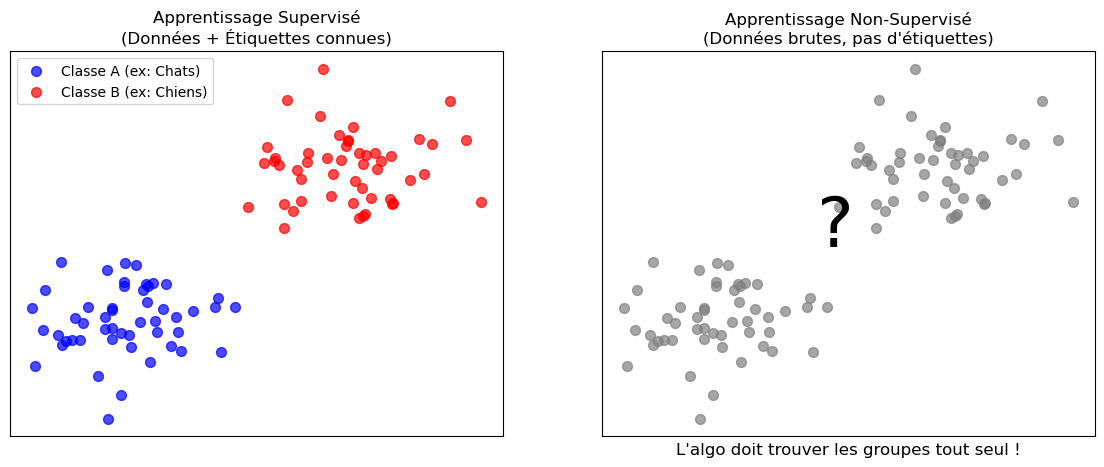

In [193]:
import matplotlib.pyplot as plt
import numpy as np

# Génération de données
np.random.seed(42)
x1 = np.random.normal(2, 1, 50)
y1 = np.random.normal(2, 1, 50)
x2 = np.random.normal(6, 1, 50)
y2 = np.random.normal(6, 1, 50)

plt.figure(figsize=(14, 5))

# 1. Apprentissage Supervisé
plt.subplot(1, 2, 1)
plt.scatter(x1, y1, c='blue', label='Classe A (ex: Chats)', s=50, alpha=0.7)
plt.scatter(x2, y2, c='red', label='Classe B (ex: Chiens)', s=50, alpha=0.7)
plt.title("Apprentissage Supervisé\n(Données + Étiquettes connues)")
plt.legend()
plt.xticks([])
plt.yticks([])

# 2. Apprentissage Non-Supervisé
plt.subplot(1, 2, 2)
plt.scatter(np.concatenate([x1, x2]), np.concatenate([y1, y2]), c='gray', s=50, alpha=0.7)
plt.title("Apprentissage Non-Supervisé\n(Données brutes, pas d'étiquettes)")
plt.text(4, 4, "?", fontsize=50, color='black', ha='center')
plt.xlabel("L'algo doit trouver les groupes tout seul !", fontsize=12)
plt.xticks([])
plt.yticks([])

plt.show()

### A. Apprentissage Supervisé
Le modèle apprend à partir d'exemples **étiquetés** (on lui donne la réponse correcte pour chaque exemple).

Deux grandes tâches :
1.  **Classification** : Prédire une catégorie (ex: Spam ou Non-Spam).
2.  **Régression** : Prédire une valeur numérique continue (ex: prix d'une maison).

**Exemple 1 : Classification simple (KNN)**

In [194]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# 1. Charger les données (Fleurs d'Iris)
iris = load_iris()
X, y = iris.data, iris.target

# 2. Séparer en entraînement et test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Créer et entraîner le modèle (KNN)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# 4. Évaluer
accuracy = model.score(X_test, y_test)
print(f"Précision KNN (Classification) : {accuracy:.2f}")

Précision KNN (Classification) : 1.00


**Exemple 2 : Régression (Prédire un salaire)**
Imaginons qu'on veuille prédire un salaire en fonction des années d'expérience.

Prédiction pour 6 ans d'expérience : 73.9 k€


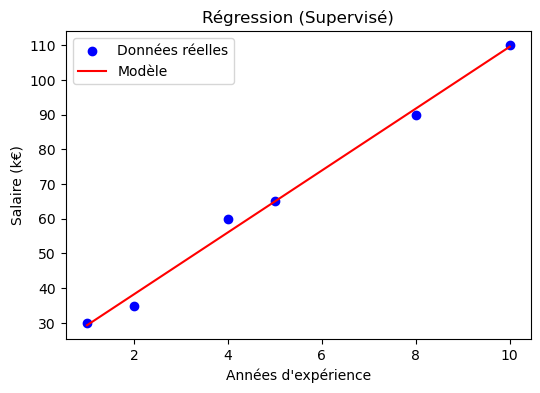

In [195]:
from sklearn.linear_model import LinearRegression

# Données fictives : Expérience (X) -> Salaire (y)
X_exp = np.array([[1], [2], [4], [5], [8], [10]])
y_sal = np.array([30, 35, 60, 65, 90, 110]) # en k€

model_reg = LinearRegression()
model_reg.fit(X_exp, y_sal)

print(f"Prédiction pour 6 ans d'expérience : {model_reg.predict([[6]])[0]:.1f} k€")

# Visualisation
plt.figure(figsize=(6, 4))
plt.scatter(X_exp, y_sal, color='blue', label='Données réelles')
plt.plot(X_exp, model_reg.predict(X_exp), color='red', label='Modèle')
plt.xlabel("Années d'expérience")
plt.ylabel("Salaire (k€)")
plt.title("Régression (Supervisé)")
plt.legend()
plt.show()

### B. Apprentissage Non-Supervisé
Le modèle apprend à partir de données **non étiquetées**. Il cherche des structures cachées.

Deux grandes tâches :
1.  **Clustering** : Regrouper des données similaires.
2.  **Réduction de dimension** : Simplifier les données pour mieux les visualiser.

**Exemple 1 : Clustering (K-Means)**
Ici, on va demander à l'IA de trouver 4 groupes de points dans des données en vrac.

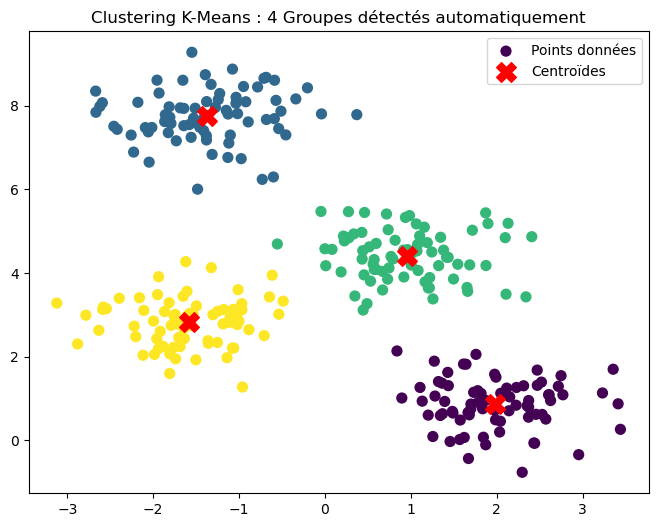

In [196]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Générer des données (300 points, 4 centres)
X_blobs, y_blobs = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# 2. Entraîner K-Means
kmeans = KMeans(n_clusters=4, n_init="auto")
kmeans.fit(X_blobs)

# 3. Visualisation
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=kmeans.labels_, s=50, cmap='viridis', label='Points données')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, marker='X', label='Centroïdes')
plt.title("Clustering K-Means : 4 Groupes détectés automatiquement")
plt.legend()
plt.show()

### B. Choisir le Nombre de Clusters : La Méthode du Coude (Elbow Method)

L'algorithme K-Means nécessite de spécifier le nombre de clusters `k` à l'avance. Mais comment choisir le bon `k`?

La **Méthode du Coude** répond à cette question:
1. Entraîner K-Means avec k = 1, 2, 3, ..., 10
2. Pour chaque k, mesurer l'inertie (compacité des clusters)
3. Tracer la courbe (k vs inertie)
4. Regarder le "coude" dans la courbe - c'est le k optimal

In [ ]:
# Méthode du Coude
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans_k = KMeans(n_clusters=k, n_init="auto", random_state=42)
    kmeans_k.fit(X_blobs)
    inertias.append(kmeans_k.inertia_)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Nombre de Clusters (k)')
plt.ylabel('Inertie (Somme des distances au centroïde)')
plt.title('Méthode du Coude - Trouvez le k optimal')
plt.grid(True, alpha=0.3)
plt.axvline(x=4, color='red', linestyle='--', label='Coude (k=4 optimal)')
plt.legend()
plt.show()

print("\n💡 INTERPRÉTATION:")
print("- L'inertie BAISSE avec plus de clusters (normal)")
print("- Cherchez le 'coude': où la diminution ralentit")
print("- Dans ce cas, k=4 est optimal (léger changement de pente)")"'''

### C. Clustering Hiérarchique et Dendrogramme

Une alternative à K-Means est le **Clustering Hiérarchique**, qui crée un arbre de clusters.

**Avantages:**
- Pas besoin de spécifier k à l'avance
- Visualisation du dendrogramme montre la structure
- Intuitive: clusters proches fusionnent progressivement

**Méthodes de liaison (linkage):**
- `single`: Distance minimale entre clusters
- `complete`: Distance maximale
- `average`: Distance moyenne
- `ward`: Minimise la variance (recommandé)

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Utiliser un sous-ensemble pour clarté
X_subset = X_blobs[:50]

# Calculer la matrice de liaison (linkage)
Z = linkage(X_subset, method='ward')

# Visualiser le dendrogramme
plt.figure(figsize=(12, 5))
dendrogram(Z, leaf_rotation=90, leaf_font_size=10)
plt.xlabel('Index des points')
plt.ylabel('Distance')
plt.title('Dendrogramme - Clustering Hiérarchique')
plt.axhline(y=15, color='red', linestyle='--', label='Seuil de coupure')
plt.legend()
plt.tight_layout()
plt.show()

print("\n💡 DENDROGRAMME:")
print("- Hauteur des branches = distance entre clusters")
print("- Couper à hauteur 15 → 4 clusters")
print("- Comparer avec le résultat K-Means précédent")"'''

**Exemple 2 : Réduction de Dimension (PCA)**
Les données Iris ont 4 dimensions (longueur/largeur sépale/pétale). C'est impossible à dessiner en 2D. 
Utilisons PCA pour "écraser" ces 4 dimensions en 2 dimensions principales, tout en gardant le maximum d'information.

Forme avant PCA : (150, 4) -> Forme après PCA : (150, 2)


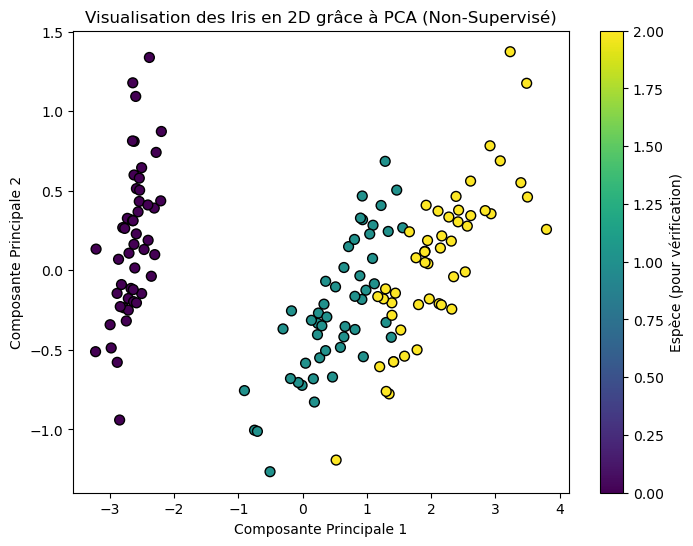

In [197]:
from sklearn.decomposition import PCA

# On reprend X (les 4 dimensions de Iris)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f"Forme avant PCA : {X.shape} -> Forme après PCA : {X_pca.shape}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.title('Visualisation des Iris en 2D grâce à PCA (Non-Supervisé)')
plt.colorbar(label='Espèce (pour vérification)')
plt.show()

### C. Apprentissage par Renforcement
Un **Agent** apprend à prendre des décisions dans un **Environnement** pour maximiser une **Récompense** ou éviter une **Punition**.
C'est la méthode utilisée pour apprendre aux IA à jouer aux échecs, à Mario ou à conduire une voiture.

#### Les Concepts
- **L'Agent** : Celui qui apprend (ex: le robot).
- **L'Environnement** : Le monde dans lequel il est (ex: le labyrinthe).
- **L'Action** : Ce que fait l'agent (ex: aller à gauche, à droite).
- **La Récompense (Reward)** : Le feedback (+1 biscuit, -1 décharge).
- **La Q-Table** : Le "cerveau" de l'agent. Un tableau où il note la valeur de chaque action dans chaque situation.

#### Exemple : La Chasse au Trésor (Q-Learning)
Un agent est dans un couloir de 6 cases : `o - - - - T` (où `o` est le départ et `T` le Trésor sans fond).
L'agent doit apprendre à aller à droite pour trouver le trésor.

In [198]:
import numpy as np
import pandas as pd
import time

# --- Configuration ---
N_STATES = 6   # Longueur du couloir
ACTIONS = ['gauche', 'droite']
EPSILON = 0.9  # Taux d'exploration (90% du temps il choisit la meilleure action connue)
ALPHA = 0.1    # Taux d'apprentissage
GAMMA = 0.9    # Facteur d'actualisation (importance du futur)
MAX_EPISODES = 15 # Nombre de fois qu'on joue

# Création de la Q-Table (Cerveau vide au départ)
# Lignes = État (position 0 à 5), Colonnes = Actions (gauche, droite)
q_table = pd.DataFrame(np.zeros((N_STATES, len(ACTIONS))), columns=ACTIONS)

# --- Fonctions du Jeu ---
def choose_action(state, q_table):
    # Stratégie Epsilon-Greedy : Parfois on explore, parfois on exploite
    if np.random.uniform() > EPSILON or (q_table.iloc[state, :] == 0).all():
        action_name = np.random.choice(ACTIONS) # Exploration (Au hasard)
    else:
        action_name = q_table.iloc[state, :].idxmax() # Exploitation (Le meilleur choix connu)
    return action_name

def get_env_feedback(state, action):
    # Simule l'environnement
    if action == 'droite':
        if state == N_STATES - 2: # Arrive au trésor (État 5 car on part de 0)
            next_state = 'terminal'
            reward = 1
        else:
            next_state = state + 1
            reward = 0
    else: # gauche
        reward = 0
        if state == 0:
            next_state = state # Mur à gauche
        else:
            next_state = state - 1
    return next_state, reward

# --- Entraînement ! ---
print("Début de l'entraînement... (Observez la Q-Table changer)")
for episode in range(MAX_EPISODES):
    state = 0 # Départ à gauche
    is_terminated = False
    
    while not is_terminated:
        action_name = choose_action(state, q_table)
        next_state, reward = get_env_feedback(state, action_name)
        
        # Mise à jour de la Q-Table (Formule du Q-Learning)
        q_predict = q_table.loc[state, action_name]
        if next_state != 'terminal':
            q_target = reward + GAMMA * q_table.iloc[next_state, :].max()
        else:
            q_target = reward # Pas de futur après le trésor
            is_terminated = True
            
        q_table.loc[state, action_name] += ALPHA * (q_target - q_predict)
        state = next_state

# Affichage final
print("\n--- Q-Table Finale (Ce que l'agent a appris) ---")
print(q_table)
print("\nInterprétation : Plus la valeur est haute, plus l'action est bonne.")
print("Notez comment 'droite' a des valeurs positives croissantes vers la fin (états 4, 3, 2...)")

Début de l'entraînement... (Observez la Q-Table changer)

--- Q-Table Finale (Ce que l'agent a appris) ---
     gauche    droite
0  0.000162  0.008346
1  0.000000  0.040500
2  0.000000  0.149089
3  0.000000  0.405861
4  0.000000  0.794109
5  0.000000  0.000000

Interprétation : Plus la valeur est haute, plus l'action est bonne.
Notez comment 'droite' a des valeurs positives croissantes vers la fin (états 4, 3, 2...)


## 4. Les Modèles Courants (Maths, Plots & Code)

Allons un peu plus loin dans le fonctionnement mathématique et visuel des modèles, avec un code pour chacun.

### A. Régression Linéaire
Le but est de trouver la droite qui passe "au plus près" de tous les points.

**La Formule** :
$$ y = w \cdot x + b $$
- $y$ : La valeur à prédire (ex: prix).
- $x$ : La donnée d'entrée (ex: surface).
- $w$ : Le poids (pente de la droite).
- $b$ : Le biais (ordonnée à l'origine).

**L'Erreur (Coût)** :
Pour trouver la meilleure droite, on minimise l'erreur quadratique moyenne (MSE) :
$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$
C'est la moyenne des carrés des écarts entre la réalité ($y_i$) et la prédiction ($\hat{y}_i$).

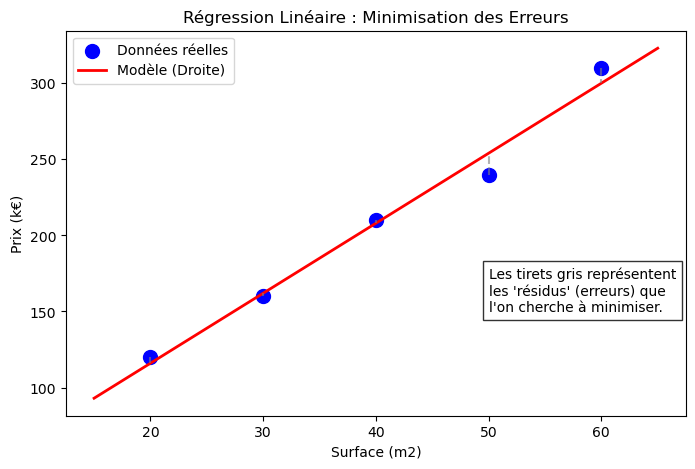

In [199]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Données : Surface (m2) vs Prix (k€)
X_reg = np.array([[20], [30], [40], [50], [60]])
y_reg = np.array([120, 160, 210, 240, 310])

model = LinearRegression()
model.fit(X_reg, y_reg)

# Prédiction pour le tracé
X_range = np.linspace(15, 65, 100).reshape(-1, 1)
y_pred_line = model.predict(X_range)
y_pred_points = model.predict(X_reg)

plt.figure(figsize=(8, 5))
plt.scatter(X_reg, y_reg, color='blue', label='Données réelles', s=100)
plt.plot(X_range, y_pred_line, color='red', label='Modèle (Droite)', linewidth=2)

# Visualiser les résidus (erreurs)
for i in range(len(X_reg)):
    plt.plot([X_reg[i], X_reg[i]], [y_reg[i], y_pred_points[i]], color='gray', linestyle='--', alpha=0.6)

plt.text(50, 150, "Les tirets gris représentent\nles 'résidus' (erreurs) que\nl'on cherche à minimiser.", fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.xlabel('Surface (m2)')
plt.ylabel('Prix (k€)')
plt.legend()
plt.title('Régression Linéaire : Minimisation des Erreurs')
plt.show()

### B. Régression Logistique (Classification)
Pour la classification binaire (ex: 0 ou 1), on utilise souvent la Régression Logistique.
Elle utilise une fonction **Sigmoïde** pour écraser la sortie entre 0 et 1, ce qui s'interprète comme une probabilité.

**La Formule** :
$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$
Si $\sigma(z) > 0.5$, on prédit la classe 1, sinon la classe 0.

**Note pratique : Les Probabilités (predict_proba)**

La fonction Sigmoïde transforme la sortie en probabilité entre 0 et 1.
Nous pouvons obtenir ces probabilités avec `.predict_proba()`:

In [ ]:
# Obtenir les PROBABILITÉS au lieu des prédictions
y_proba = log_reg.predict_proba(X_test)  # shape: (n_samples, n_classes)

print(f"Probabilités (premières 5 prédictions):\n")
print(y_proba[:5])
print(f"\nColonne 0: P(classe 0), Colonne 1: P(classe 1), etc.")

# Exemple pour une observation
idx = 0
print(f"\nPour l'observation 0:")
for class_idx, prob in enumerate(y_proba[idx]):
    print(f"  P(classe {class_idx}) = {prob:.3f}")

# Les probabilités réelles donnent plus d'info que juste predict()
y_pred = log_reg.predict(X_test)  # Juste la classe (0, 1, 2, ...)
print(f"\nPredict (juste la classe): {y_pred[:5]}")
print(f"Predict_proba (probabilités): {y_proba[:5]}")
print(f"\n💡 Les probas sont utiles pour ROC curves, threshold adjustment, etc.")"'''

Précision Régression Logistique : 1.00


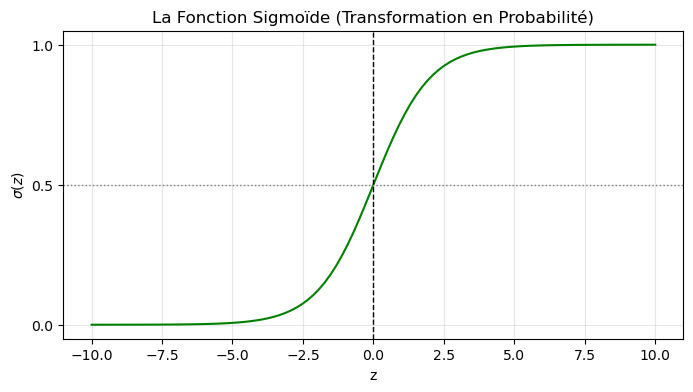

In [200]:
from sklearn.linear_model import LogisticRegression

# Utilisons les données Iris pour une classification multiclasse
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

print(f"Précision Régression Logistique : {log_reg.score(X_test, y_test):.2f}")

# Visualisation de la Sigmoïde
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
phi_z = sigmoid(z)

plt.figure(figsize=(8, 4))
plt.plot(z, phi_z, color='green')
plt.axvline(0.0, color='black', lw=1, linestyle='--')
plt.axhline(0.5, color='gray', lw=1, linestyle=':')
plt.yticks([0.0, 0.5, 1.0])
plt.title('La Fonction Sigmoïde (Transformation en Probabilité)')
plt.xlabel('z')
plt.ylabel('$\sigma(z)$')
plt.grid(True, alpha=0.3)
plt.show()

Génération de la courbe d'apprentissage pour la Régression Logistique...


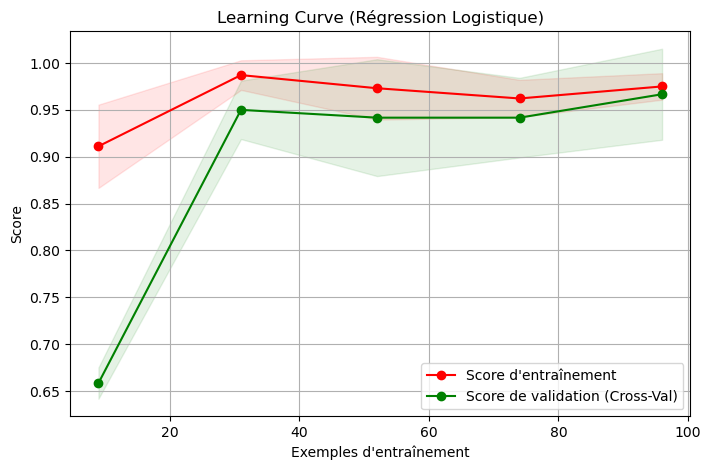

In [201]:
print("Génération de la courbe d'apprentissage pour la Régression Logistique...")
plot_learning_curve(log_reg, "Learning Curve (Régression Logistique)", X_train, y_train, cv=5)

### C. Autres Modèles Importants

#### 1. Arbres de Décision
- **Principe** : Pose une série de questions (Si X > 5 alors...) pour arriver à une feuille (réponse).
- **Avantage** : Très facile à interpréter.

Précision Arbre de Décision : 1.00


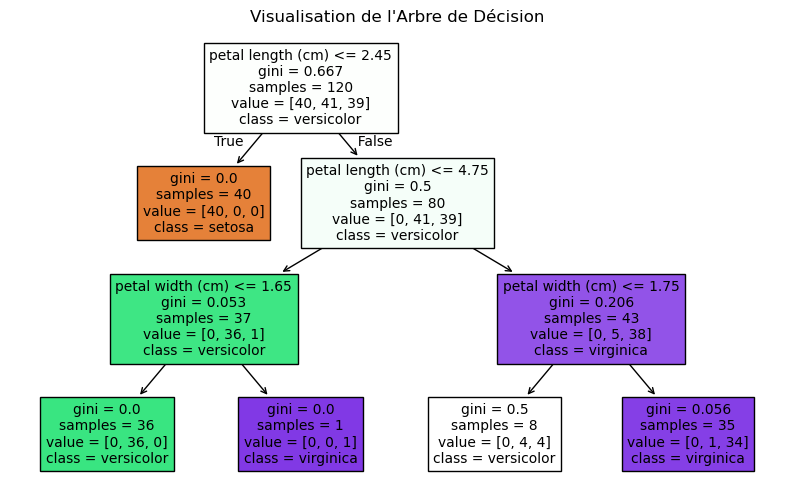

In [202]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(X_train, y_train)

print(f"Précision Arbre de Décision : {tree_model.score(X_test, y_test):.2f}")

# Visualisation de l'arbre
plt.figure(figsize=(10, 6))
plot_tree(tree_model, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.title("Visualisation de l'Arbre de Décision")
plt.show()

Génération de la courbe d'apprentissage pour l'Arbre de Décision...


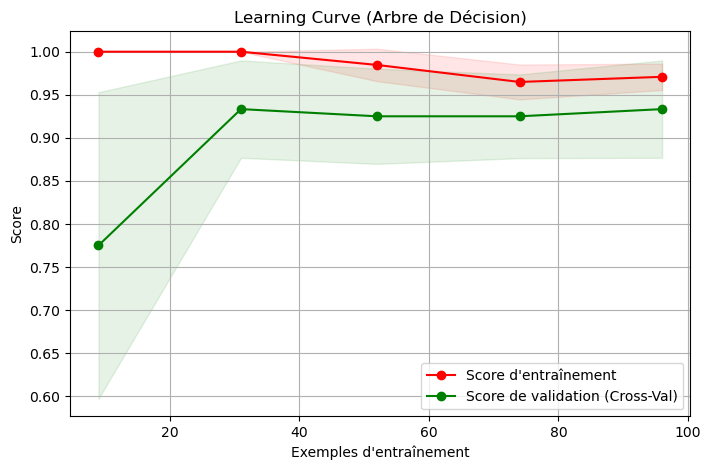

In [203]:
print("Génération de la courbe d'apprentissage pour l'Arbre de Décision...")
plot_learning_curve(tree_model, "Learning Curve (Arbre de Décision)", X_train, y_train, cv=5)

#### 2. K-Nearest Neighbors (KNN)
- **Principe** : "Dis-moi qui sont tes voisins, je te dirai qui tu es."
- **Maths** : Utilise la distance Euclidienne : $d(x, y) = \sqrt{\sum (x_i - y_i)^2}$.
- *Note : Le code pour KNN a déjà été montré dans la section 3.*

#### 3. Support Vector Machines (SVM)
- **Principe** : Chercher la frontière (hyperplan) qui sépare les classes avec la plus grande marge possible.

In [204]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear') # 'linear' est plus simple à comprendre, 'rbf' est plus puissant
svm_model.fit(X_train, y_train)

print(f"Précision SVM : {svm_model.score(X_test, y_test):.2f}")

Précision SVM : 1.00


Génération de la courbe d'apprentissage pour SVM...


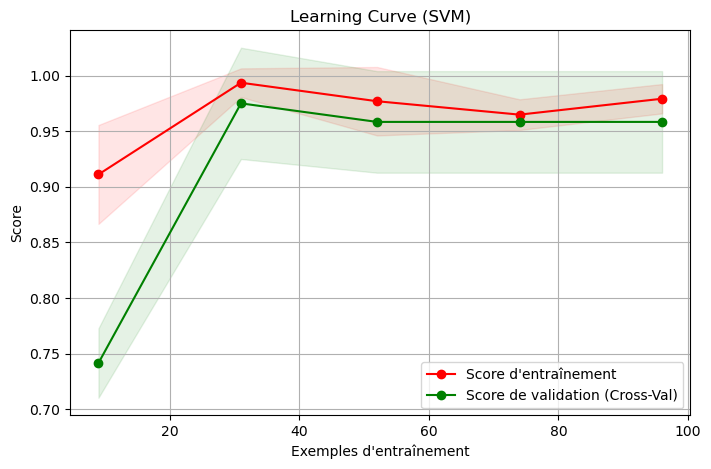

In [205]:
print("Génération de la courbe d'apprentissage pour SVM...")
plot_learning_curve(svm_model, "Learning Curve (SVM)", X_train, y_train, cv=5)

#### 4. Naive Bayes
- **Principe** : Basé sur les probabilités (Théorème de Bayes). Suppose que les caractéristiques sont indépendantes entre elles.
- **Usage** : Très utilisé pour le texte (Spam vs Ham).

In [206]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print(f"Précision Naive Bayes : {nb_model.score(X_test, y_test):.2f}")

Précision Naive Bayes : 1.00


Génération de la courbe d'apprentissage pour Naive Bayes...


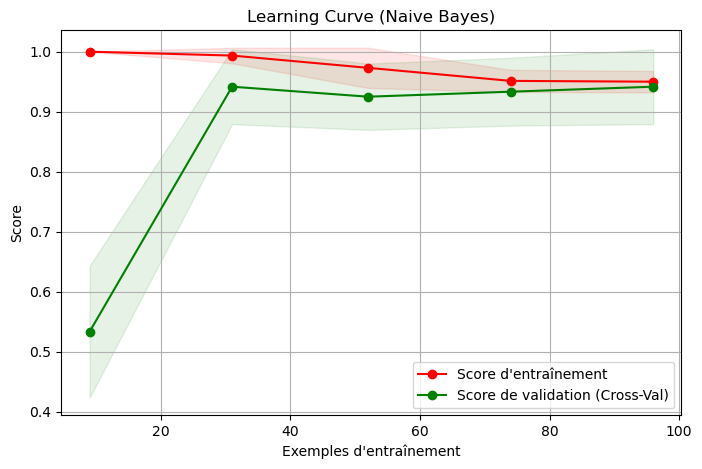

In [207]:
print("Génération de la courbe d'apprentissage pour Naive Bayes...")
plot_learning_curve(nb_model, "Learning Curve (Naive Bayes)", X_train, y_train, cv=5)

#### 5. Random Forest
- **Principe** : Une démocratie d'arbres de décision. On entraîne plein d'arbres (ex: 100) sur des parties aléatoires des données, et ils votent.

In [208]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print(f"Précision Random Forest : {rf_model.score(X_test, y_test):.2f}")

Précision Random Forest : 1.00


Génération de la courbe d'apprentissage pour Random Forest...


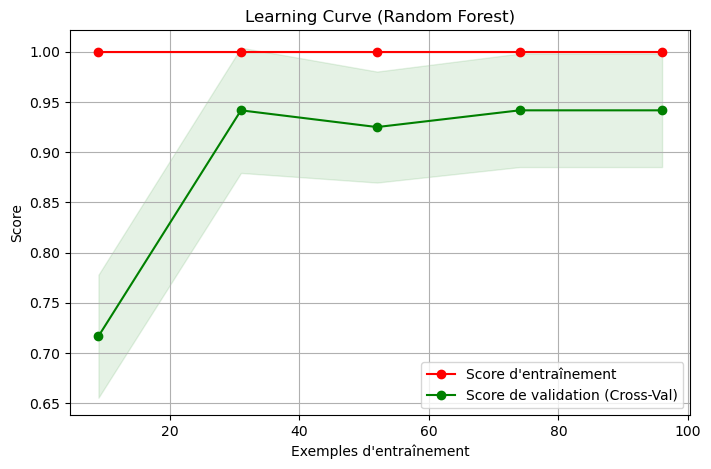

In [209]:
print("Génération de la courbe d'apprentissage pour Random Forest...")
plot_learning_curve(rf_model, "Learning Curve (Random Forest)", X_train, y_train, cv=5)

### D. Réseaux de Neurones (Deep Learning)
Ils sont composés de neurones artificiels interconnectés.

**Le Neurone Artificiel** :
$$ y = f(\sum_{i} w_i \cdot x_i + b) $$
- Il fait une somme pondérée des entrées ($w_i \cdot x_i$)
- Il ajoute un biais ($b$)
- Il passe le tout dans une **fonction d'activation** ($f$) pour décider s'il doit "s'activer" ou non.

C'est la brique de base de ChatGPT, de la reconnaissance faciale, etc.
Ici, on utilise un **MLP (Multi-Layer Perceptron)** simple.

In [210]:
from sklearn.neural_network import MLPClassifier

# Un réseau avec 2 couches cachées de 10 neurones chacune
mlp_model = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
mlp_model.fit(X_train, y_train)

print(f"Précision Réseau de Neurones (MLP) : {mlp_model.score(X_test, y_test):.2f}")

Précision Réseau de Neurones (MLP) : 0.93


Génération de la courbe d'apprentissage pour MLP...


/opt/miniconda3/envs/cours/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


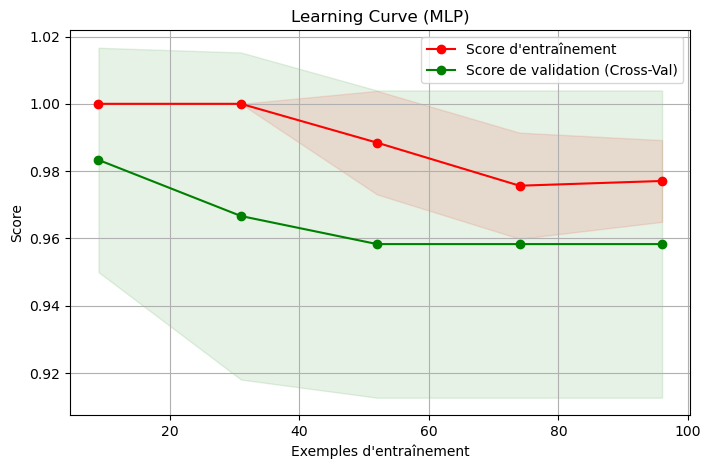

In [211]:
print("Génération de la courbe d'apprentissage pour MLP...")
plot_learning_curve(mlp_model, "Learning Curve (MLP)", X_train, y_train, cv=5)

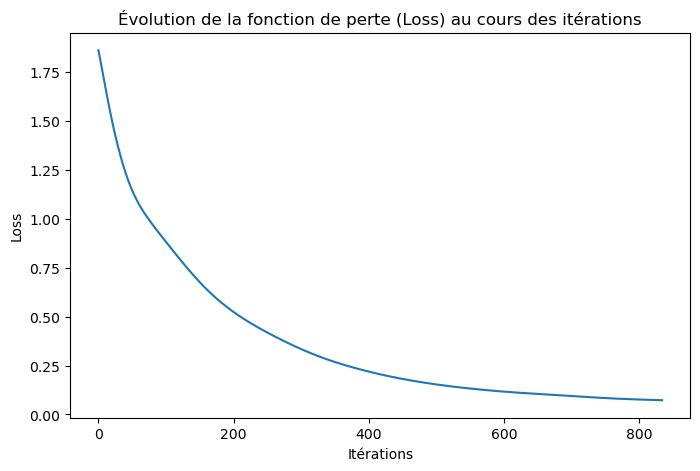

In [212]:
plt.figure(figsize=(8, 5))
plt.plot(mlp_model.loss_curve_)
plt.title("Évolution de la fonction de perte (Loss) au cours des itérations")
plt.xlabel("Itérations")
plt.ylabel("Loss")
plt.show()

#### Entraînement avec Early Stopping

Le **Early Stopping** arrête l'entraînement automatiquement quand la performance sur un ensemble de validation cesse de s'améliorer. C'est essentiel pour éviter l'overfitting.

**Concept:**
- Diviser données en Train / Validation
- Pendant l'entraînement, surveiller la performance sur Validation
- Si elle ne s'améliore pas pendant N itérations → arrêter
- Cela prévient l'overfitting automatiquement

In [ ]:
# Entraînement avec Early Stopping
mlp_early = MLPClassifier(
    hidden_layer_sizes=(50, 30),
    max_iter=1000,
    early_stopping=True,           # Activer early stopping
    validation_fraction=0.2,        # 20% des données pour validation
    n_iter_no_change=10,            # Arrêter après 10 itérations sans amélioration
    random_state=42
)

print("Entraînement avec early stopping...")
mlp_early.fit(X_train_scaled, y_train)

# Visualiser la courbe de perte
plt.figure(figsize=(10, 5))
plt.plot(mlp_early.loss_curve_, label='Entraînement')
if hasattr(mlp_early, 'validation_scores_'):
    plt.plot(mlp_early.validation_scores_, label='Validation')
plt.xlabel('Itérations')
plt.ylabel('Loss / Score')
plt.title('Early Stopping: Arrêt automatique de l\'entraînement')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n✓ Entraînement arrêté après {len(mlp_early.loss_curve_)} itérations")
print(f"  (au lieu de 1000 max)")
print(f"\nPrécision: {mlp_early.score(X_test_scaled, y_test):.3f}")"'''

## 5. Évaluation et Optimisation

Savoir entraîner un modèle, c'est bien. Savoir s'il est performant et pourquoi, c'est mieux.

### A. Au-delà de la "Précision" (Accuracy)
La précision globale (`accuracy`) est parfois trompeuse. Imaginez un modèle qui doit détecter des maladies rares (1 cas sur 100). S'il prédit "Toujours Sain", il a 99% de précision... mais il est inutile !

Pour évaluer plus finement, on utilise :
- **Matrice de Confusion** : Un tableau qui montre où le modèle se trompe.
- **Précision (Precision)** : Quand le modèle dit "Oui", a-t-il souvent raison ?
- **Rappel (Recall)** : Quand c'est "Oui" dans la réalité, le modèle le trouve-t-il souvent ?
- **F1-Score** : Une moyenne harmonique entre Précision et Rappel.

Rapport de classification :

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



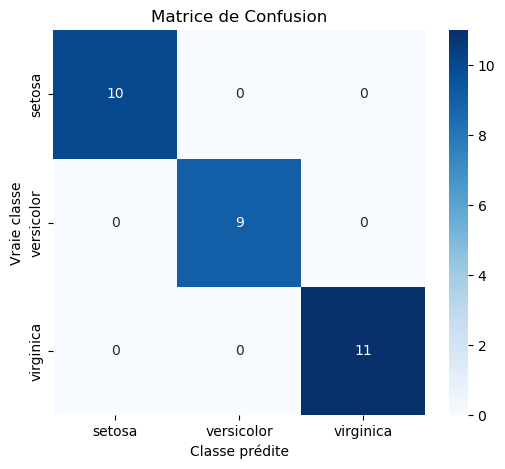

In [213]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Évaluation détaillée du modèle Random Forest
y_pred_rf = rf_model.predict(X_test)

print("Rapport de classification :\n")
print(classification_report(y_test, y_pred_rf, target_names=iris.target_names))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.title('Matrice de Confusion')
plt.show()

### A.2. Courbes ROC et AUC : Évaluation Avancée

Au-delà de la confusion matrice, les **Courbes ROC (Receiver Operating Characteristic)** permettent de visualiser le compromis entre le taux de vrais positifs et le taux de faux positifs.

**Pourquoi c'est important?**
- Particulièrement utile pour les données déséquilibrées
- Montre comment le modèle se comporte avec différents seuils de décision
- L'**AUC (Area Under Curve)** donne un score unique (1 = parfait, 0.5 = aléatoire)

**Contexte médical:** Pour diagnostiquer le cancer :
- Seuil bas (0.3) : Détecte plus de malades, mais faux positifs
- Seuil moyen (0.5) : Équilibre
- Seuil haut (0.7) : Plus sûr, mais risque de manquer des cas

In [ ]:
from sklearn.metrics import roc_curve, auc

# Pour la courbe ROC: besoin des PROBABILITÉS, pas des prédictions binaires
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Calculer la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Visualisation
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC - Évaluation du Modèle')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.3f}")

In [ ]:
# Impact du SEUIL DE DÉCISION
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n=== Effet du seuil sur les métriques ===\n")
print(f"{'Seuil':<8} {'Précision':<12} {'Rappel':<12} {'F1-Score':<12}")
print("-" * 50)

for threshold in [0.3, 0.5, 0.7, 0.9]:
    y_pred_t = (y_proba >= threshold).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"{threshold:<8.1f} {prec:<12.3f} {rec:<12.3f} {f1:<12.3f}")

print("\n💡 OBSERVATIONS:")
print("- Seuil bas → Rappel ↑, Faux positifs ↑")
print("- Seuil haut → Faux positifs ↓, Faux négatifs ↑")
print("- Choix du seuil dépend du contexte (médical, spam, etc.)")

### B. Overfitting vs Underfitting

C'est LE concept fondamental à comprendre.

- **Underfitting (Sous-apprentissage)** : Le modèle est trop simple (ex: une droite pour suivre une courbe). Il ne comprend pas la logique des données. "L'élève paresseux".
- **Overfitting (Surapprentissage)** : Le modèle est trop complexe. Il apprend le bruit et les détails insignifiants des données d'entraînement par cœur. Il sera excellent en entraînement mais nul en test. "L'élève qui apprend tout par cœur sans rien comprendre".
- **Good Fit (Bon ajustement)** : Le modèle a trouvé l'équilibre.

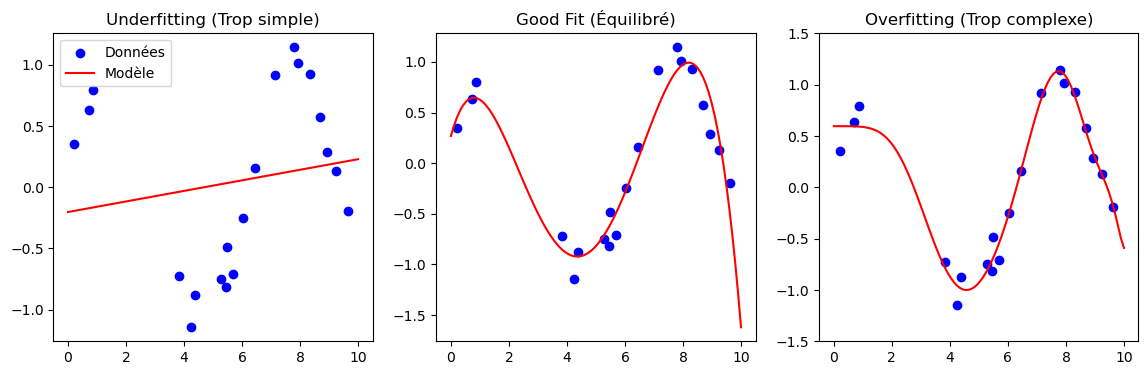

In [214]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Génération de données courbes avec du bruit
np.random.seed(0)
X_poly = np.sort(np.random.rand(20) * 10)
y_poly = np.sin(X_poly) + np.random.randn(20) * 0.1
X_poly = X_poly[:, np.newaxis]

X_plot = np.linspace(0, 10, 100)[:, np.newaxis]

plt.figure(figsize=(14, 4))

# 1. Underfitting (Modèle linéaire simple)
plt.subplot(1, 3, 1)
model1 = LinearRegression()
model1.fit(X_poly, y_poly)
plt.scatter(X_poly, y_poly, color='blue', label='Données')
plt.plot(X_plot, model1.predict(X_plot), color='red', label='Modèle')
plt.title("Underfitting (Trop simple)")
plt.legend()

# 2. Good Fit (Polynôme degré 4)
plt.subplot(1, 3, 2)
model2 = make_pipeline(PolynomialFeatures(4), LinearRegression())
model2.fit(X_poly, y_poly)
plt.scatter(X_poly, y_poly, color='blue')
plt.plot(X_plot, model2.predict(X_plot), color='red')
plt.title("Good Fit (Équilibré)")

# 3. Overfitting (Polynôme degré 15)
plt.subplot(1, 3, 3)
model3 = make_pipeline(PolynomialFeatures(15), LinearRegression())
model3.fit(X_poly, y_poly)
plt.scatter(X_poly, y_poly, color='blue')
plt.plot(X_plot, model3.predict(X_plot), color='red')
plt.ylim(-1.5, 1.5)
plt.title("Overfitting (Trop complexe)")

plt.show()

### C. La Validation Croisée (Cross-Validation)

Pour être sûr que notre score n'est pas un coup de chance lié à la façon dont on a coupé nos données (Train/Test), on utilise la validation croisée.
On découpe les données en 5 parts (folds). On entraîne sur 4 et on teste sur 1, et on tourne 5 fois.

In [215]:
from sklearn.model_selection import cross_val_score

# Validation croisée sur le modèle Random Forest
scores = cross_val_score(rf_model, X, y, cv=5)

print("Scores de validation croisée :", scores)
print(f"Précision moyenne : {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")

Scores de validation croisée : [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Précision moyenne : 0.97 (+/- 0.04)


## 6. Ingénierie des Données (Preprocessing)

Souvent, les modèles de Machine Learning fonctionnent beaucoup mieux si les données sont préparées correctement.
L'une des techniques les plus importantes est la **mise à l'échelle (Scaling)**.

Certains algorithmes (comme les SVM et les Réseaux de Neurones) sont très sensibles à l'échelle des données. Si une variable varie entre 0 et 1 et une autre entre 0 et 1000, l'algorithme va accorder trop d'importance à la seconde via ses calculs de distance.

**StandardScaler** transforme les données pour qu'elles aient une moyenne de 0 et un écart-type de 1.

In [216]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retestons le SVM avec les données mises à l'échelle
# (Nous réentraînons un nouveau modèle sur les données transformées)
print("Entraînement SVM sur données scalées...")
svm_scaled = SVC(random_state=42) 
svm_scaled.fit(X_train_scaled, y_train)
print(f"Précision SVM (Scaled) : {svm_scaled.score(X_test_scaled, y_test):.2f}")

# Pareil pour le MLP (qui en a grand besoin !)
print("Entraînement MLP sur données scalées...")
mlp_scaled = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
mlp_scaled.fit(X_train_scaled, y_train)
print(f"Précision MLP (Scaled) : {mlp_scaled.score(X_test_scaled, y_test):.2f}")

Entraînement SVM sur données scalées...
Précision SVM (Scaled) : 1.00
Entraînement MLP sur données scalées...
Précision MLP (Scaled) : 0.97


## 7. Optimisation des Hyperparamètres

Jusqu'à présent, nous avons choisi les paramètres (comme `n_estimators=100` pour la Forêt Aléatoire ou `C=1.0` pour le SVM) un peu au hasard.
Comment trouver les **meilleurs** paramètres ?

La **Recherche sur Grille (Grid Search)** teste toutes les combinaisons possibles que vous lui donnez.

In [217]:
from sklearn.model_selection import GridSearchCV

# Définissons la grille des paramètres à tester pour le Random Forest
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

print("Recherche des meilleurs paramètres pour Random Forest (cela peut prendre quelques secondes)...")
rf = RandomForestClassifier(random_state=42)

# GridSearch va tester chaque combinaison (Cross-Validation incluse !)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres trouvés : {grid_search.best_params_}")
print(f"Meilleure précision moyenne (validation) : {grid_search.best_score_:.2f}")

# On peut récupérer le meilleur modèle directement
best_model = grid_search.best_estimator_
print(f"Précision sur le Test Set (Meilleur Modèle) : {best_model.score(X_test, y_test):.2f}")

Recherche des meilleurs paramètres pour Random Forest (cela peut prendre quelques secondes)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Meilleurs paramètres trouvés : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 10}
Meilleure précision moyenne (validation) : 0.96
Précision sur le Test Set (Meilleur Modèle) : 1.00


## 8. Deep Learning Avancé : Vision par Ordinateur (Computer Vision)

La **Vision par Ordinateur** est le domaine qui permet aux machines de "voir" et d'analyser des images.
C'est la technologie derrière la reconnaissance faciale, les voitures autonomes, et l'analyse médicale.

### Le concept clé : Les Pixels
Pour un ordinateur, une image n'est qu'une grille de nombres (pixels).
- Une image en noir et blanc de 8x8 pixels = 64 nombres (de 0 à 16 ou 0 à 255).

### Les Convolutional Neural Networks (CNN) - Théorie
Aujourd'hui, l'état de l'art (State-of-the-Art) utilise des **CNN**.
Au lieu de regarder tous les pixels en même temps (comme notre MLP précédent), un CNN utilise des **filtres** (convolutions) pour détecter des formes :
1.  **Couches basses** : Détectent des bords, des lignes.
2.  **Couches moyennes** : Détectent des formes (yeux, roues).
3.  **Couches hautes** : Reconnaissent des objets entiers (chats, voitures).

*(Note : Pour utiliser des vrais CNN, il faudrait `TensorFlow` ou `PyTorch`. Ici, nous allons utiliser notre MLP sur des images de chiffres manuscrits pour comprendre le principe !)*

### Pratique : Reconnaissance de Chiffres Manuscrits (Digits Dataset)
Nous allons entraîner notre modèle à lire des chiffres !

Format des images : (1797, 8, 8)
Format des données pour le modèle : (1797, 64)


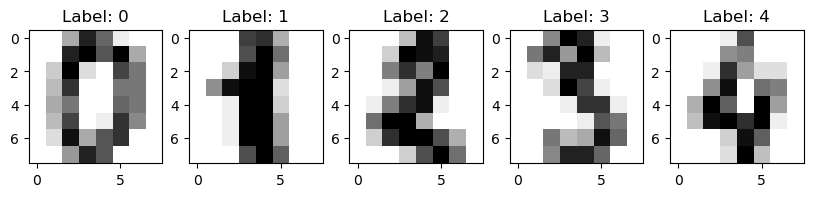

In [218]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

# 1. Charger les données (Images 8x8 pixels de chiffres 0-9)
digits = load_digits()
X_images = digits.images
X_data = digits.data # Version aplatie (64 pixels)
y_digits = digits.target

print(f"Format des images : {X_images.shape}")
print(f"Format des données pour le modèle : {X_data.shape}")

# 2. Visualiser quelques exemples
plt.figure(figsize=(10, 4))
for index, (image, label) in enumerate(zip(X_images[0:5], y_digits[0:5])):
    plt.subplot(1, 5, index + 1)
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title(f'Label: {label}')
plt.show()

In [219]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# 3. Séparer Train / Test
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_data, y_digits, test_size=0.3, random_state=42)

# 4. Entraîner le MLP (Réseau de Neurones) sur les pixels
# Comme ce sont des images plus complexes, on utilise un réseau un peu plus gros
mlp_vision = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
print("Entraînement en cours sur les images...")
mlp_vision.fit(X_train_d, y_train_d)

# 5. Évaluation
y_pred_d = mlp_vision.predict(X_test_d)
print(f"Précision sur les chiffres : {accuracy_score(y_test_d, y_pred_d):.2f}")

# Regardons où il se trompe !
print("\nRapport de classification :")
print(classification_report(y_test_d, y_pred_d))

Entraînement en cours sur les images...
Précision sur les chiffres : 0.97

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        53
           1       0.96      0.96      0.96        50
           2       0.96      0.98      0.97        47
           3       1.00      0.94      0.97        54
           4       0.98      1.00      0.99        60
           5       0.97      0.97      0.97        66
           6       0.96      0.98      0.97        53
           7       1.00      0.96      0.98        55
           8       0.87      0.95      0.91        43
           9       0.97      0.95      0.96        59

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



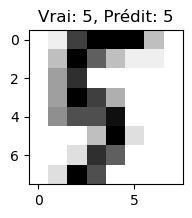

In [220]:
# 6. Testons sur une image spécifique
index_test = 8
image_test = X_test_d[index_test].reshape(8, 8)
true_label = y_test_d[index_test]
predicted_label = mlp_vision.predict([X_test_d[index_test]])[0]

plt.figure(figsize=(2, 2))
plt.imshow(image_test, cmap=plt.cm.gray_r)
plt.title(f"Vrai: {true_label}, Prédit: {predicted_label}")
plt.show()

#### CountVectorizer vs TF-IDF: Quelle Représentation?

Dans l'exemple précédent, nous avons utilisé **CountVectorizer** (bag-of-words).
Mais c'est une approche naive! Les mots communs (le, de, et) reçoivent trop de poids.

**TF-IDF (Term Frequency - Inverse Document Frequency)** est plus intelligent:
- **TF (Term Frequency)**: Combien de fois le mot apparaît? (comme CountVectorizer)
- **IDF (Inverse Document Frequency)**: Moins le mot est commun, plus il est important
  - Mots rares dans le corpus → IDF haut → plus de poids
  - Mots communs → IDF bas → moins de poids

**Résultat:** Les mots significatifs (ex: "mauvais", "excellent") dominent

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Même données d'entraînement
train_texts = [
    "Ce film est incroyable, j'adore !", 
    "Un chef d'oeuvre absolu, scénario parfait.",
    "Quel ennui, je me suis endormi.",
    "Nul, nul, nul. Perte de temps."
]
train_labels = ["Positif", "Positif", "Négatif", "Négatif"]

# Comparaison: CountVectorizer vs TfidfVectorizer
count_vec = CountVectorizer()
tfidf_vec = TfidfVectorizer()

X_count = count_vec.fit_transform(train_texts)
X_tfidf = tfidf_vec.fit_transform(train_texts)

print("\n=== COMPARAISON ===\n")
print(f"CountVectorizer shape: {X_count.shape}")
print(f"TfidfVectorizer shape: {X_tfidf.shape}")

print("\nMots les plus importants (TF-IDF):")
feature_names = tfidf_vec.get_feature_names_out()
for i, doc in enumerate(X_tfidf):
    print(f"\nTexte {i}: '{train_texts[i][:30]}...'")
    top_indices = doc.toarray()[0].argsort()[-3:][::-1]
    for idx in top_indices:
        if X_tfidf[i, idx] > 0:
            print(f"  - '{feature_names[idx]}': {X_tfidf[i, idx]:.3f}")

print("\n💡 Observation: 'incroyable', 'chef', 'ennui' reçoivent plus de poids")"'''

## 9. IA Générative et Traitement du Langage (NLP)

Depuis 2022 et l'arrivée de ChatGPT, l'IA a pris un tournant majeur avec l'**IA Générative**.

### Comprendre les LLMs (Large Language Models)
- **C'est quoi ?** Ce sont des modèles entraînés sur des quantités titanesques de texte (tout internet ou presque).
- **Comment ça marche ?** Fondamentalement, ils ne font que **prédire le mot suivant**.
    - *"Le chat est sur le..."* -> *"tapis"* (Probabilité élevée), *"toit"* (Moyenne), *"soleil"* (Faible).
- **Le Transformer :** C'est l'architecture révolutionnaire (2017) qui permet aux LLMs de comprendre le contexte sur de très longues phrases, contrairement aux anciens RNN.

### Pratique : Analyse de Sentiments (NLP Classique)
Avant de générer du texte, apprenons à la machine à le comprendre.
Nous allons construire un modèle capable de dire si une critique de film est **Positive** ou **Négative**.

In [221]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# 1. Un petit jeu de données (Critiques de films)
# Dans la vraie vie, on aurait des milliers de critiques !
train_texts = [
    "Ce film est incroyable, j'adore !", 
    "Un chef d'oeuvre absolu, scénario parfait.",
    "Les acteurs sont géniaux, à voir.",
    "Quel ennui, je me suis endormi.",
    "Nul, nul, nul. Perte de temps.",
    "Scénario ridicule et acteurs mauvais.",
    "Pas mal, mais un peu long.",
    "Superbe réalisation et musique."
]
train_labels = ["Positif", "Positif", "Positif", "Négatif", "Négatif", "Négatif", "Positif", "Positif"]

# 2. Vectorisation (Transformer le texte en nombres)
# La machine ne lit pas le français, elle compte les mots !
# "Bag of Words" : On compte la fréquence de chaque mot.

# 3. Création du Pipeline (Vectoriser -> Classifier)
# On utilise Naive Bayes, très efficace pour le texte
model_nlp = make_pipeline(CountVectorizer(), MultinomialNB())

# 4. Entraînement
model_nlp.fit(train_texts, train_labels)
print("Modèle NLP entraîné !")

Modèle NLP entraîné !


In [222]:
# 5. Testons le modèle sur de nouvelles phrases
test_sentences = [
    "C'était vraiment super !",
    "Je déteste ce film, c'est une honte.",
    "Les acteurs jouent mal.",
    "Un moment magique au cinéma."
]

predictions = model_nlp.predict(test_sentences)

for sentence, sentiment in zip(test_sentences, predictions):
    print(f"Critique : '{sentence}' -> Sentiment : {sentiment}")

Critique : 'C'était vraiment super !' -> Sentiment : Positif
Critique : 'Je déteste ce film, c'est une honte.' -> Sentiment : Positif
Critique : 'Les acteurs jouent mal.' -> Sentiment : Positif
Critique : 'Un moment magique au cinéma.' -> Sentiment : Positif


### Introduction à la Génération de Texte (Théorie)
Pour générer du texte, on utilise aujourd'hui des réseaux comme GPT (Generative Pre-trained Transformer).

L'idée de base est une **Chaîne de Markov** simplifiée :
On regarde une séquence de mots et on tire au sort le mot suivant selon les probabilités apprises.

*(Pour aller plus loin, vous pourriez utiliser la librairie `transformers` de Hugging Face pour charger un vrai modèle GPT-2 ou BERT, mais cela demande plus de puissance de calcul et d'installation !)*

## 10. Éthique et Biais en IA

Une idée reçue dangereuse : *"C'est une machine, c'est neutre, c'est objectif."*
❌ **FAUX.** L'IA apprend ce qu'on lui montre. Si les données sont biaisées, l'IA sera biaisée (et parfois pire).

### Démonstration Pratique : Le Recruteur Biaisé
Imaginons un modèle qui filtre les CVs pour une entreprise.
Nous allons créer un jeu de données où, historiquement, l'entreprise n'a embauché personne habitant dans le code postal "99000", même très compétents.

In [223]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

# 1. Création du Dataset Biaisé
# Candidats : Experience (0-10 ans), Score Test (0-100), Code Postal (0 ou 1)
# 0 = Quartier Favorisé, 1 = Quartier Discriminé
n_samples = 500
np.random.seed(42)

experience = np.random.randint(0, 11, n_samples)
test_score = np.random.randint(50, 101, n_samples)
zip_code = np.random.choice([0, 1], n_samples) # 50% de chaque

# La règle d'embauche "bête" du passé :
# Si Score > 70 ET Code Postal == 0 (Favorisé) -> Embauché (1)
# Si Code Postal == 1 (Discriminé) -> Rejeté (0), même si bon score !
# C'est un biais énorme et injuste.
hired = ((test_score > 70) & (zip_code == 0)).astype(int)

df_bias = pd.DataFrame({
    'Experience': experience,
    'Score': test_score,
    'Zone_Habitation': zip_code, # 0 ou 1
    'Embauché': hired
})

print("Aperçu des données historiques (biaisées) :")
print(df_bias.head())

Aperçu des données historiques (biaisées) :
   Experience  Score  Zone_Habitation  Embauché
0           6     83                0         1
1           3    100                0         1
2          10     90                1         0
3           7     56                1         0
4           4     53                1         0


In [224]:
# 2. Entraînement du Modèle
# Le modèle va-t-il apprendre à être discriminatoire ? OUI.
X_bias = df_bias[['Experience', 'Score', 'Zone_Habitation']]
y_bias = df_bias['Embauché']

model_recruteur = LogisticRegression()
model_recruteur.fit(X_bias, y_bias)

# Regardons l'importance des "poids" que le modèle donne aux critères
coefs = pd.DataFrame(model_recruteur.coef_, columns=X_bias.columns)
print("Poids accordés par le modèle :")
print(coefs)
# Si le poids de 'Zone_Habitation' est très négatif, c'est la preuve du biais.

Poids accordés par le modèle :
   Experience     Score  Zone_Habitation
0   -0.008583  0.212038        -7.099031


In [225]:
# 3. Testons l'injustice
# Prenons deux candidats IDENTIQUES (Même expérience, même score excellent)
# Seule différence : leur adresse.

candidat_A = pd.DataFrame({'Experience': [5], 'Score': [95], 'Zone_Habitation': [0]}) # Favorisé
candidat_B = pd.DataFrame({'Experience': [5], 'Score': [95], 'Zone_Habitation': [1]}) # Discriminé

pred_A = model_recruteur.predict(candidat_A)[0]
pred_B = model_recruteur.predict(candidat_B)[0]

print(f"Candidat A (Zone 0) embauché ? : {'OUI' if pred_A==1 else 'NON'}")
print(f"Candidat B (Zone 1) embauché ? : {'OUI' if pred_B==1 else 'NON'}")

# Conclusion : Le modèle a appris à discriminer sur le code postal.
# Solution : Ne jamais donner de colonnes sensibles (race, genre, adresse) au modèle si on veut éviter ça (Drop column) !

Candidat A (Zone 0) embauché ? : OUI
Candidat B (Zone 1) embauché ? : NON


## 11. Comprendre le "Pourquoi" : Explicabilité (XAI) et Hypersurface

"Comment le modèle prend-il sa décision ?"
C'est la question clé. Pour y répondre, nous devons visualiser la **Frontière de Décision**.

###  Visualisation Interactive (Simulée) : L'impact des Hyperparamètres
Prenons l'algorithme des K-Plus Proches Voisins (**KNN**).
- Si on regarde seulement 1 voisin (`n_neighbors=1`), la frontière est très découpée (Overfitting).
- Si on regarde 50 voisins, la frontière est très lisse (Underfitting ?).

Voyons cela visuellement sur le jeu de données Iris (2 colonnes seulement pour pouvoir dessiner).

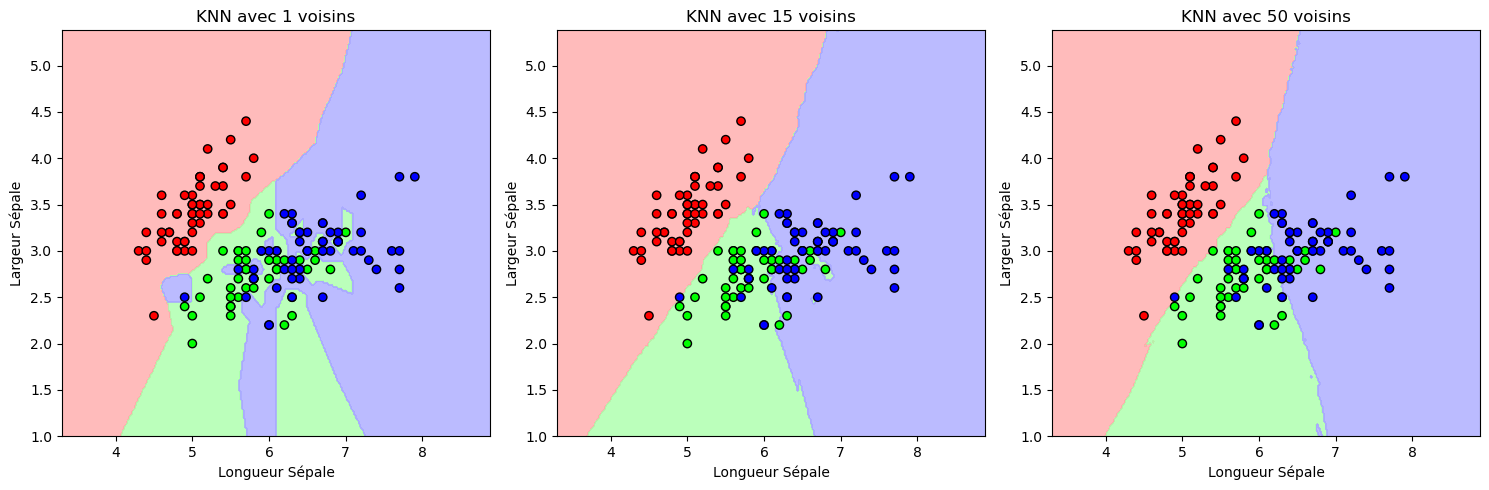

In [226]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris

# 1. Préparer les données (Iris, seulement 2 features pour la 2D)
iris = load_iris()
X_vis = iris.data[:, :2] # Sépales seulement
y_vis = iris.target

# Fonction pour dessiner la frontière
def plot_decision_boundary(clf, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']), alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['#FF0000', '#00FF00', '#0000FF']), edgecolors='k')
    plt.title(title)
    plt.xlabel('Longueur Sépale')
    plt.ylabel('Largeur Sépale')

# 2. La "Boucle Interactive"
# On va afficher 3 graphiques côte à côte pour comparer
plt.figure(figsize=(15, 5))

neighbors_settings = [1, 15, 50]
for i, n_neighbors in enumerate(neighbors_settings):
    # Entraînement sur le vif
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_vis, y_vis)
    
    # Dessin
    plt.subplot(1, 3, i + 1)
    plot_decision_boundary(clf, X_vis, y_vis, f"KNN avec {n_neighbors} voisins")

plt.tight_layout()
plt.show()

### Feature Importance (L'Importance des Caractéristiques)
Une autre façon de comprendre le modèle est de se demander : **"Quelle colonne du tableau a le plus compté ?"**

Pour notre **Random Forest** (entraîné plus haut sur le Titanic), c'est facile à obtenir.
Est-ce l'âge ? Le prix du billet ? Le sexe ?

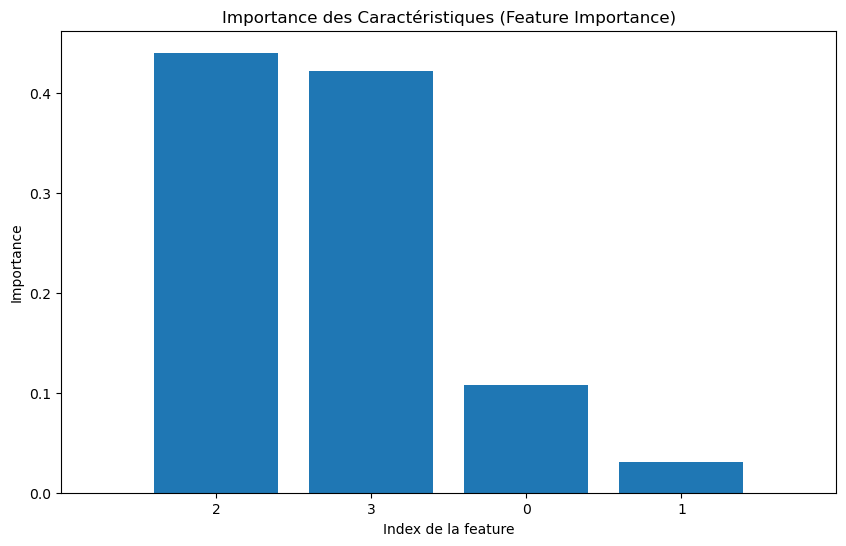

Plus la barre est haute, plus l'information a été cruciale pour la décision.


In [227]:
# Récupérons notre modèle Random Forest (rf_model)
# (Assurez-vous d'avoir exécuté la partie Random Forest avant)

import pandas as pd
import matplotlib.pyplot as plt

# On suppose que rf_model est déjà entraîné
# On récupère les noms des colonnes (si possible, sinon on met des noms génériques)
feature_names = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"] 
# Note : C'est une simplification, dans le vrai code avec OneHotEncoder, il y a plus de colonnes.
# Mais pour l'explication, regardons ce que le modèle nous dit.

# Si le modèle a été entraîné avec un Pipeline, c'est plus complexe d'extraire les noms.
# Faisons simple :
if hasattr(rf_model, 'feature_importances_'):
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    plt.title("Importance des Caractéristiques (Feature Importance)")
    plt.bar(range(len(importances)), importances[indices], align="center")
    # On ne met pas les noms précis car ils dépendent du processing, mais on voit la forme
    plt.xticks(range(len(importances)), indices) 
    plt.xlim([-1, len(importances)])
    plt.xlabel("Index de la feature")
    plt.ylabel("Importance")
    plt.show()
    print("Plus la barre est haute, plus l'information a été cruciale pour la décision.")
else:
    print("Ce modèle ne fournit pas directement les feature importances.")